In [2]:
import dpluspy
import demes 
import moments 
import msprime
import numpy as np
import pandas
import scipy

In [3]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'

In [4]:
# Merge replicate tables together
trial_tbls0 = []
for ii in range(100):
    try:
        _tbl = pandas.read_csv(f"trials/pulse_LRT_model0_rep{ii}.csv")
        trial_tbls0.append(_tbl)
    except:
        print(f"missing trial {ii}")
tbl0 = pandas.concat(trial_tbls0)
tbl0.to_csv("model0_tbl.csv", index=False)

trial_tbls1 = []
for ii in range(100):
    try:
        _tbl = pandas.read_csv(f"trials/pulse_LRT_model1_rep{ii}.csv")
        trial_tbls1.append(_tbl)
    except:
        print(f"missing trial {ii}")
tbl1 = pandas.concat(trial_tbls1)
tbl1.to_csv("model1_tbl.csv", index=False)

missing trial 1
missing trial 5
missing trial 6
missing trial 10
missing trial 13
missing trial 14
missing trial 20
missing trial 24
missing trial 25
missing trial 28
missing trial 31
missing trial 33
missing trial 34
missing trial 37
missing trial 40
missing trial 42
missing trial 46
missing trial 47
missing trial 48
missing trial 49
missing trial 53
missing trial 58
missing trial 59
missing trial 60
missing trial 61
missing trial 62
missing trial 69
missing trial 70
missing trial 75
missing trial 84
missing trial 86
missing trial 88
missing trial 90
missing trial 94
missing trial 96
missing trial 97
missing trial 98


In [19]:
# Max observed D
print(np.min(tbl0["D_naive"]), np.max(tbl0["D_naive"]))
print(np.min(tbl0["D_adj0"]), np.max(tbl0["D_adj0"]))
print(np.min(tbl0["D_adj1"]), np.max(tbl0["D_adj1"]))

print(np.min(tbl1["D_naive"]), np.max(tbl1["D_naive"]))
print(np.min(tbl1["D_adj0"]), np.max(tbl1["D_adj0"]))
print(np.min(tbl1["D_adj1"]), np.max(tbl1["D_adj1"]))

0.0032564653198521 2.796933804046642
-0.605723559963199 0.7479717676325519
0.0004276982256429 0.3498627338864233
18.12609644809491 73.20061822832277
-229.4262502943554 450.6902115748634
1.3474686828728446 6.851194437619897


In [23]:
# Find the alpha = 0.05 threshold for the (0, 0.5, 0.5) Chi2 distribution
alpha = 0.05
x = 5.14
print(moments.Godambe.sum_chi2_ppf(x, (0, 0.5, 0.5)))

0.004151674628543933


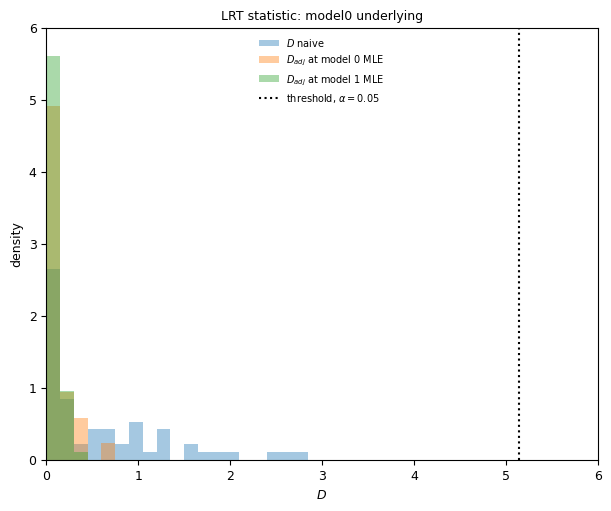

In [7]:
# Plot LRT statistics for model0
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

bins = np.linspace(0, 3, 21)
counts_naive_0 = np.histogram(tbl0["D_naive"], bins)[0]
counts_adj0_0 = np.histogram(tbl0["D_adj0"], bins)[0]
counts_adj0_1 = np.histogram(tbl0["D_adj1"], bins)[0]

# bins for plotting
_bins = np.concatenate([bins[:-1], [bins[-2] + bins[-2] - bins[-3]]])
plt.hist(bins[:-1], bins=_bins, weights=counts_naive_0, color="tab:blue", 
    density=True, alpha=0.4, label="$D$ naive",)
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_0, color="tab:orange", 
    density=True, alpha=0.4, label="$D_{adj}$ at model 0 MLE")
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_1, color="tab:green",  
    density=True, alpha=0.4, label="$D_{adj}$ at model 1 MLE",)

#
#df = 1
#xx = np.linspace(0, _bins[-1], 300)
#yy = scipy.stats.chi2.pdf(xx, df)
#plt.plot(xx, yy, color="black", label=r"$\chi^2_1$ PDF")

# Plot the rejection threshold
ax.vlines(x, 0, 10, color="black", linestyles="dotted", 
    label=r"threshold, $\alpha=0.05$")

ax.set_ylim(0, 6)
ax.set_xlim(0, 6)
ax.set_ylabel("density")
ax.set_xlabel("$D$")
ax.legend(framealpha=0, loc="upper center")
ax.set_title("LRT statistic: model0 underlying")
plt.savefig("figures/fig_LRT_distrs_model0.pdf")

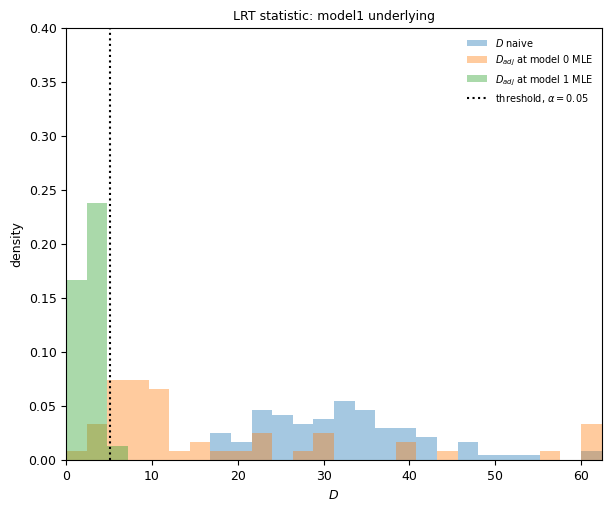

In [8]:
# Plot LRT statistics for model1
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

bins = np.concatenate([np.linspace(0, 60, 26), [1e3]])
counts_naive_0 = np.histogram(tbl1["D_naive"], bins)[0]
counts_adj0_0 = np.histogram(tbl1["D_adj0"], bins)[0]
counts_adj0_1 = np.histogram(tbl1["D_adj1"], bins)[0]

# bins for plotting
_bins = np.concatenate([bins[:-1], [bins[-2] + bins[-2] - bins[-3]]])
plt.hist(bins[:-1], bins=_bins, weights=counts_naive_0, color="tab:blue", 
    density=True, alpha=0.4, label="$D$ naive",)
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_0, color="tab:orange", 
    density=True, alpha=0.4, label="$D_{adj}$ at model 0 MLE")
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_1, color="tab:green",  
    density=True, alpha=0.4, label="$D_{adj}$ at model 1 MLE",)

#df = 1
#xx = np.linspace(0, _bins[-1], 300)
#yy = scipy.stats.chi2.pdf(xx, df)
#plt.plot(xx, yy, color="black", label=r"$\chi^2_1$ PDF")

# Plot the rejection threshold
ax.vlines(x, 0, 10, color="black", linestyles="dotted", 
    label=r"threshold, $\alpha=0.05$")

ax.set_ylim(0, 0.4)
ax.set_xlim(0, _bins[-1])
ax.set_ylabel("density")
ax.set_xlabel("$D$")
ax.legend(framealpha=0)
ax.set_title("LRT statistic: model1 underlying")
plt.savefig("figures/fig_LRT_distrs_model1.pdf")

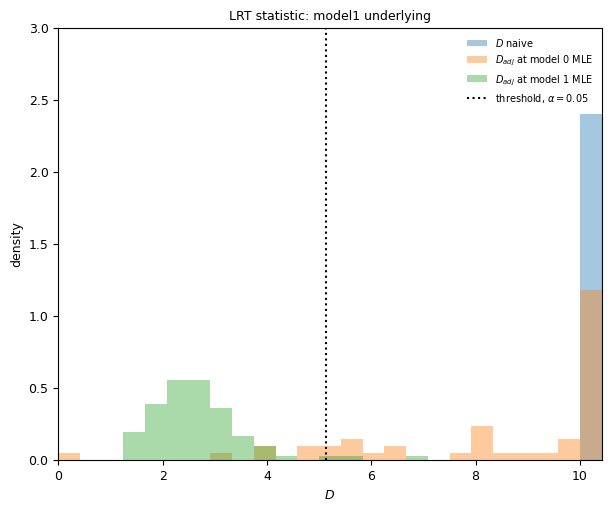

In [14]:
# Plot LRT statistics for model1
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

bins = np.concatenate([np.linspace(0, 10, 25), [1e4]])
counts_naive_0 = np.histogram(tbl1["D_naive"], bins)[0]
counts_adj0_0 = np.histogram(tbl1["D_adj0"], bins)[0]
counts_adj0_1 = np.histogram(tbl1["D_adj1"], bins)[0]

# bins for plotting
_bins = np.concatenate([bins[:-1], [bins[-2] + bins[-2] - bins[-3]]])
plt.hist(bins[:-1], bins=_bins, weights=counts_naive_0, color="tab:blue", 
    density=True, alpha=0.4, label="$D$ naive",)
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_0, color="tab:orange", 
    density=True, alpha=0.4, label="$D_{adj}$ at model 0 MLE")
plt.hist(bins[:-1], bins=_bins, weights=counts_adj0_1, color="tab:green",  
    density=True, alpha=0.4, label="$D_{adj}$ at model 1 MLE",)

# Plot the rejection threshold
ax.vlines(x, 0, 10, color="black", linestyles="dotted", 
    label=r"threshold, $\alpha=0.05$")

ax.set_ylim(0, 3)
ax.set_xlim(0, _bins[-1])
ax.set_ylabel("density")
ax.set_xlabel("$D$")
ax.legend(framealpha=0)
ax.set_title("LRT statistic: model1 underlying")
plt.savefig("figures/fig_LRT_distrs_model1_zoomed.pdf")

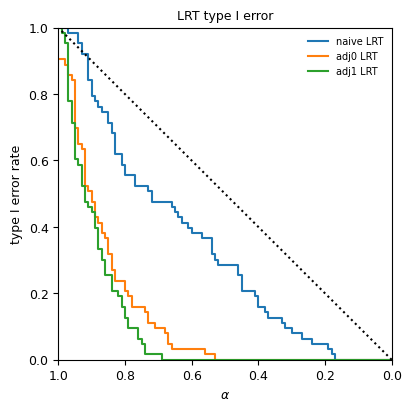

In [16]:
# Plot type I error rates (model0 results)
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")

p_naive = np.array(tbl0["p_naive"])
p_adj0 = np.array(tbl0["p_adj0"])
p_adj1 = np.array(tbl0["p_adj1"])

alphas = np.linspace(0, 1, 101)
naive_error = np.array([np.count_nonzero(p_naive < a) / len(p_naive) for a in alphas])
adj0_error = np.array([np.count_nonzero(p_adj0 < a) / len(p_adj0) for a in alphas])
adj1_error = np.array([np.count_nonzero(p_adj1 < a) / len(p_adj1) for a in alphas])
                      
plt.step(alphas, naive_error, color="tab:blue", label="naive LRT")
plt.step(alphas, adj0_error, color="tab:orange", label="adj0 LRT")
plt.step(alphas, adj1_error, color="tab:green", label="adj1 LRT")

ax.plot([0, 1], [0, 1], color="black", linestyle="dotted")
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
ax.set_ylabel("type I error rate")
ax.set_xlabel(r"$\alpha$")
ax.invert_xaxis()
ax.legend(framealpha=0)
ax.set_title("LRT type I error")
plt.savefig("figures/fig_model0_typeI_error.pdf")